# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hassanmustafa119/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import duckdb
import pandas as pd
import numpy as np

print("✅ Imports successful")

✅ Imports successful


In [2]:
from huggingface_hub import login
from getpass import getpass

HF_TOKEN = getpass("Enter your Hugging Face token: ")

login(token=HF_TOKEN)

print("✅ Hugging Face authentication successful")

Enter your Hugging Face token: ··········
✅ Hugging Face authentication successful


In [3]:
con = duckdb.connect()

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

con.execute("DROP SECRET IF EXISTS hf_secret")

con.execute("""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN ?
)
""", [HF_TOKEN])

print("✅ DuckDB connected to Hugging Face")

✅ DuckDB connected to Hugging Face


In [4]:
test_query = """
SELECT *
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
LIMIT 5
"""

test_df = con.sql(test_query).df()

print("Rows returned:", len(test_df))
display(test_df)

Rows returned: 5


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [40]:
# Section 1 — Build the ranked action queue

action_df = test_df.copy()

# Add the held-out model score
action_df["rf_score"] = rf_scores

# Basic reason flags
action_df["low_clicks"] = (
    (action_df["march_impressions"] >= 100) &
    (action_df["march_clicks"] <= 5)
)

action_df["low_ctr"] = (
    (action_df["march_impressions"] >= 100) &
    (action_df["march_ctr"] <= 0.01)
)

action_df["position_opportunity"] = (
    (action_df["march_avg_position"] >= 4) &
    (action_df["march_avg_position"] <= 20) &
    (action_df["march_impressions"] >= 100)
)

action_df["observed_decline"] = (
    action_df["impression_change_pct"] <= -20
)

# Human-readable reason code
action_df["reason_code"] = np.select(
    [
        action_df["observed_decline"],
        action_df["low_clicks"],
        action_df["low_ctr"],
        action_df["position_opportunity"]
    ],
    [
        "OBSERVED_IMPRESSION_DECLINE",
        "LOW_CLICKS",
        "LOW_CTR",
        "POSITION_OPPORTUNITY"
    ],
    default="MODEL_FLAG"
)

# Human-readable action
action_df["recommended_action"] = np.select(
    [
        action_df["observed_decline"],
        action_df["low_clicks"],
        action_df["low_ctr"],
        action_df["position_opportunity"]
    ],
    [
        "Review recent content/performance changes",
        "Review search-result click opportunity",
        "Review title and snippet relevance",
        "Review content relevance and on-page alignment"
    ],
    default="Review page before taking action"
)

# Rank by the held-out model score
action_df = action_df.sort_values(
    "rf_score",
    ascending=False
).reset_index(drop=True)

action_df["priority_rank"] = np.arange(
    1,
    len(action_df) + 1
)

print("Action queue rows:", len(action_df))

display(
    action_df[
        [
            "priority_rank",
            "reason_code",
            "recommended_action",
            "rf_score",
            "march_impressions",
            "march_clicks",
            "march_ctr",
            "march_avg_position",
            "impression_change_pct"
        ]
    ].head(20)
)

Action queue rows: 7038


,priority_rank,reason_code,recommended_action,rf_score,march_impressions,march_clicks,march_ctr,march_avg_position,impression_change_pct
0,1,OBSERVED_IMPRESSION_DECLINE,Review recent content/performance changes,1.000,154.0,0.0,0.000000,4.371016,-98.701299
1,2,LOW_CLICKS,Review search-result click opportunity,1.000,142.0,1.0,0.007042,5.732135,133.098592
2,3,LOW_CLICKS,Review search-result click opportunity,1.000,200.0,1.0,0.005000,7.473026,418.000000
3,4,LOW_CLICKS,Review search-result click opportunity,0.995,388.0,0.0,0.000000,78.886486,3.865979
4,5,LOW_CLICKS,Review search-result click opportunity,0.995,160.0,0.0,0.000000,6.512616,199.375000
5,6,OBSERVED_IMPRESSION_DECLINE,Review recent content/performance changes,0.995,113.0,0.0,0.000000,42.986380,-81.415929
6,7,LOW_CLICKS,Review search-result click opportunity,0.995,453.0,1.0,0.002208,6.257057,36.644592
7,8,LOW_CLICKS,Review search-result click opportunity,0.995,137.0,0.0,0.000000,15.717742,137.226277
8,9,OBSERVED_IMPRESSION_DECLINE,Review recent content/performance changes,0.995,1836.0,0.0,0.000000,3.546497,-64.923747
9,10,LOW_CLICKS,Review search-result click opportunity,0.995,131.0,0.0,0.000000,7.014020,9.923664


### Ranked actions + reason codes

The action queue ranks content using the Random Forest score generated on a client-grouped holdout set. Each ranked item is paired with a simple reason code and a human-readable recommended action.

The queue is intended as **decision-support**: pages near the top are worth reviewing first because the measured signals indicate a higher likelihood of the observed decline pattern. The score does not establish that a specific content change will improve performance.

Reason codes provide additional context:

* **OBSERVED_IMPRESSION_DECLINE** — March-to-April impressions declined by at least 20%.
* **LOW_CLICKS** — the page had at least 100 impressions but five or fewer clicks.
* **LOW_CTR** — the page had at least 100 impressions and CTR at or below 1%.
* **POSITION_OPPORTUNITY** — the observed average position was between 4 and 20 with at least 100 impressions.
* **MODEL_FLAG** — the model ranked the page for review but none of the simple reason-code rules applied.

The ranking is therefore a prioritization tool, not an automatic recommendation to change a page.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use and limits

This playbook is intended for SEO, content, and analytics teams as a **decision-support tool** for prioritizing content review.

The ranked queue helps a reviewer identify which content records should be investigated first based on the measured signals and the model score. The reason codes provide a simple explanation of the observed pattern, such as impression decline or low clicks.

The playbook does not automatically determine what caused a performance change. It does not establish that a title change, content update, or other intervention will improve search performance. The recommendations are **directional** and should be validated by a human using additional context.

The playbook is most appropriate when the underlying measurement definitions, data coverage, and time periods remain comparable to those used to build the queue. Changes in tracking, search behavior, site structure, data availability, or content mix may make the recommendations less reliable.

The output should therefore be treated as a prioritized review list rather than an automatic content-decision system.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review + the no-go list

Every item in the action queue requires human review before any content change is made.

A reviewer should check:

* whether the observed performance change is large enough to matter;
* whether the page had sufficient impressions or clicks for the signal to be meaningful;
* whether the data is complete and comparable across the measured periods;
* whether there were known site, tracking, indexing, seasonality, or search-environment changes;
* whether the page's search intent and content are still relevant;
* whether recent edits or technical changes could explain the observed movement;
* whether the recommended action is appropriate for the specific page.

The following actions should **not be automated** by this playbook:

* publishing or deleting content;
* changing titles, descriptions, or page copy automatically;
* changing search strategy based only on the model score;
* declaring a page successful or unsuccessful without human review;
* claiming that an intervention caused a performance change;
* making irreversible content or technical changes.

The playbook is designed to prioritize investigation, not to replace editorial, SEO, or technical judgment.


In [41]:
# Section 3 — Human review checks

review_checks = pd.DataFrame({
    "check": [
        "Sufficient search volume",
        "Data completeness",
        "Comparable measurement periods",
        "Recent content or technical changes",
        "Search intent and relevance",
        "Known external or seasonal effects"
    ],
    "required_before_action": [True, True, True, True, True, True]
})

print("Human review checks:", len(review_checks))
display(review_checks)

Human review checks: 6


,check,required_before_action
0,Sufficient search volume,True
1,Data completeness,True
2,Comparable measurement periods,True
3,Recent content or technical changes,True
4,Search intent and relevance,True
5,Known external or seasonal effects,True


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring / retrain triggers

The playbook should be monitored for changes in the data and in the usefulness of its recommendations.

Retraining or review should be considered when:

* the distribution of key inputs such as impressions, clicks, CTR, or average position changes substantially from the development data;
* the rate of observed impression declines changes substantially over time;
* model discrimination on a later labeled period falls materially compared with the held-out evaluation;
* the relationship between the input signals and the observed decline pattern changes;
* data coverage or tracking definitions change;
* new search, site, or measurement conditions make the existing signals less comparable.

A practical monitoring process should compare these measures over time rather than assuming that the current thresholds remain valid indefinitely.

These triggers indicate that the playbook should be reviewed or potentially retrained. They do not imply that retraining alone will improve performance.


In [42]:
# Section 4 — Baseline monitoring statistics

monitoring_baseline = pd.DataFrame({
    "metric": [
        "Rows in evaluation set",
        "Observed decline rate",
        "Median March impressions",
        "Median March clicks",
        "Median March CTR",
        "Median March average position"
    ],
    "baseline_value": [
        len(action_df),
        action_df["decline_label"].mean(),
        action_df["march_impressions"].median(),
        action_df["march_clicks"].median(),
        action_df["march_ctr"].median(),
        action_df["march_avg_position"].median()
    ]
})

print("Monitoring baseline created:")
display(monitoring_baseline)

Monitoring baseline created:


,metric,baseline_value
0,Rows in evaluation set,7038.000000
1,Observed decline rate,0.523018
2,Median March impressions,360.000000
3,Median March clicks,1.000000
4,Median March CTR,0.001969
5,Median March average position,8.892738


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### Exports for the paper

The ranked action queue and monitoring baseline are exported to `work/outputs/` so they can be reused in the accompanying paper.

The queue contains the priority rank, reason code, recommended action, model score, and supporting performance signals. The monitoring file records the baseline statistics used to describe the evaluation population.

These exports are intended for reproducibility and reporting. They do not contain client names, URLs, or private search queries.


In [43]:
# Section 5 — Export the action queue and monitoring baseline

from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Export ranked action queue
queue_export = action_df[
    [
        "priority_rank",
        "reason_code",
        "recommended_action",
        "rf_score",
        "march_impressions",
        "march_clicks",
        "march_ctr",
        "march_avg_position",
        "impression_change_pct"
    ]
].copy()

queue_path = output_dir / "content_action_queue.csv"
queue_export.to_csv(queue_path, index=False)

# Export monitoring baseline
baseline_path = output_dir / "monitoring_baseline.csv"
monitoring_baseline.to_csv(baseline_path, index=False)

print("Queue exported to:", queue_path)
print("Baseline exported to:", baseline_path)
print("Queue rows exported:", len(queue_export))

Queue exported to: work/outputs/content_action_queue.csv
Baseline exported to: work/outputs/monitoring_baseline.csv
Queue rows exported: 7038


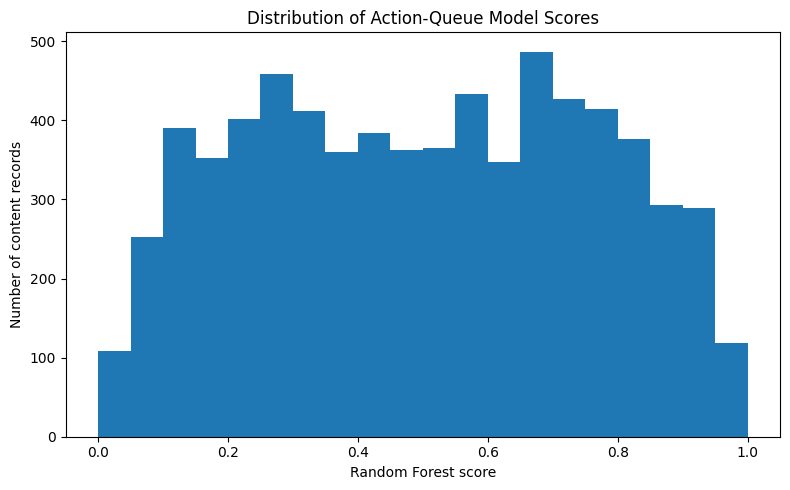

Figure exported to: work/outputs/action_queue_score_distribution.png


In [44]:
# Model score distribution for reporting

plt.figure(figsize=(8, 5))

plt.hist(
    action_df["rf_score"],
    bins=20
)

plt.xlabel("Random Forest score")
plt.ylabel("Number of content records")
plt.title("Distribution of Action-Queue Model Scores")

plt.tight_layout()

figure_path = output_dir / "action_queue_score_distribution.png"
plt.savefig(figure_path, dpi=150)
plt.show()

print("Figure exported to:", figure_path)

## Self-check

Before you submit, confirm each line honestly:

- ✔️ Every section above is filled — markdown thinking AND the code that backs it
- ✔️ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✔️ No client names, URLs, or private queries anywhere
- ✔️ My claims use careful words: observed, measured, directional, decision-support
- ✔️ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.